<a href="https://colab.research.google.com/github/zyan-007/learning-stash-code/blob/main/multiclass.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [33]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.optimizers import Adam

In [34]:
df = pd.read_csv('voters.csv')
df.head()

,age,income_k,candidate
0,56.8,132.7,1
1,73.6,147.7,0
2,66.1,30.0,0
3,32.0,44.3,0
4,36.6,68.7,2


In [35]:
x = df[['age', 'income_k']].to_numpy()
y = df['candidate'].to_numpy()

In [36]:
x.shape, y.shape

((1500, 2), (1500,))

In [37]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=0, stratify=y)

In [38]:
floor = (np.bincount(y_train) / len(y_train)) * 100
floor

array([26.58333333, 33.75      , 23.5       , 16.16666667])

In [39]:
classes = np.unique(y_train)
classes

array([0, 1, 2, 3])

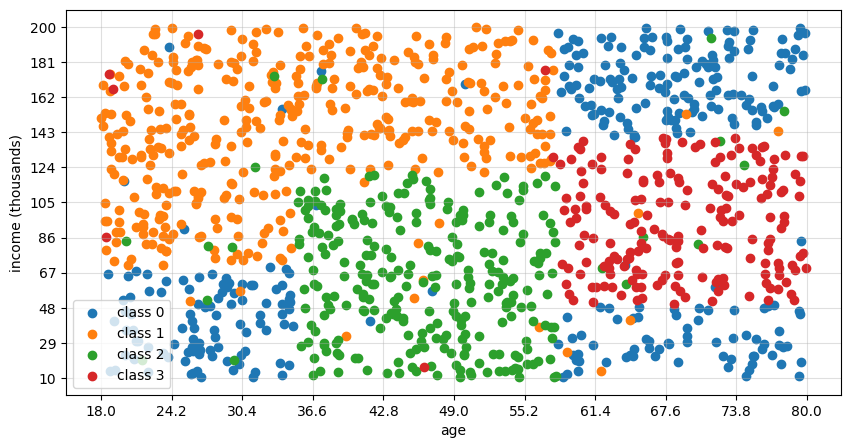

In [40]:
class_0 = y_train == 0
class_1 = y_train == 1
class_2 = y_train == 2
class_3 = y_train == 3

plt.figure(figsize=(10, 5))
plt.scatter(x_train[class_0, 0], x_train[class_0, 1], label='class 0')
plt.scatter(x_train[class_1, 0], x_train[class_1, 1], label='class 1')
plt.scatter(x_train[class_2, 0], x_train[class_2, 1], label='class 2')
plt.scatter(x_train[class_3, 0], x_train[class_3, 1], label='class 3')

plt.xticks(np.linspace(18, 80, 11))
plt.yticks(np.linspace(10, 200, 11))
plt.xlabel('age')
plt.ylabel('income (thousands)')
plt.grid(alpha=0.4)

plt.legend()
plt.show()

In [41]:
np.ptp(x_train, axis=0)

array([ 61.9, 189.5])

In [42]:
from tensorflow.keras.layers import Normalization

scale = Normalization(axis = -1)
scale.adapt(x_train)
x_train_scaled = scale(x_train)

In [43]:
np.ptp(x_train_scaled, axis=0)

array([3.4804795, 3.4401014], dtype=float32)

In [44]:
model = Sequential([
    Dense(units = 15, activation='relu', name='layer1'),
    Dense(units = 8, activation='relu', name='layer2'),
    Dense(units = 4, activation = 'linear', name='layer3')
])

In [45]:
model.compile(loss=SparseCategoricalCrossentropy(from_logits=True), optimizer=Adam(learning_rate=1e-3))

In [46]:
model.fit(x_train_scaled, y_train, epochs=100)

Epoch 1/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.3458
Epoch 2/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.2618
Epoch 3/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.1692
Epoch 4/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.0596
Epoch 5/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9469
Epoch 6/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.8425
Epoch 7/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7625
Epoch 8/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7072
Epoch 9/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6733
Epoch 10/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6507
Epoch 11/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6346
Epoch 12/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6222
Epoch 13/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6119
Epoch 14/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6019
Epoch 15/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.5927
Epoc

In [47]:
prediction = model.predict(x_train_scaled)
prediction

38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


array([[ 3.345547  ,  0.08245376, -1.5950977 ,  5.1447062 ],
       [ 3.058088  ,  0.10866386, -0.6189431 , -0.15721986],
       [-0.14144194, -0.15122578,  3.935769  , -1.0924907 ],
       ...,
       [ 0.4459709 ,  0.6458005 , -0.31519762,  1.3826736 ],
       [-1.3927753 ,  3.1751337 , -1.9931616 , -2.5008047 ],
       [ 1.9691086 , -0.84734976,  5.379169  , -1.8616184 ]],
      dtype=float32)

In [51]:
y_pred = np.argmax(prediction, axis=1)
y_pred

array([3, 0, 2, ..., 3, 1, 2])

In [56]:
y_pred.shape, y_train.shape

((1200,), (1200,))

In [57]:
accuracy = np.mean(y_pred == y_train)
print(accuracy * 100)

93.08333333333333


In [58]:
x_test_scaled = scale(x_test)
prediction_test = model.predict(x_test_scaled)
y_test_pred = np.argmax(prediction_test, axis=1)
accuracy_test = np.mean(y_test_pred == y_test)
print(accuracy_test * 100)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
91.66666666666666


In [59]:
prob_test = tf.nn.softmax(prediction_test).numpy()

print(prob_test.shape)                          # (300, 4)
print(prob_test.min(), prob_test.max())         # both between 0 and 1
print(prob_test.sum(axis=1)[:5])                # first 5 row sums, each ≈ 1.0
print(np.allclose(prob_test.sum(axis=1), 1))    # True if every row sums to 1

y_test_pred_prob = np.argmax(prob_test, axis=1)
print(np.all(y_test_pred_prob == y_test_pred))  # True if logits and probs give same classes

(300, 4)
1.3623898e-05 0.999135
[0.99999994 1.0000001  0.9999999  0.99999994 0.99999994]
True
True
